In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
import json

In [3]:
gpt_oss = "../results/gpt-oss-120b_testing_results.jsonl"
gpt_nano = "../results/gpt-5-nano-2025-08-07_testing_results.jsonl"
gpt_pro = "../results/gpt-5.2-2025-12-11_testing_results.jsonl"
llama = "../results/llama-3.3-70b-instruct_testing_results.jsonl"
files = [gpt_oss, gpt_nano, gpt_pro, llama]
results = []
for f in files:
    with open(f,"r") as input_file:
        for l in input_file:
            results.append(json.loads(l))


In [62]:
df = pd.DataFrame.from_dict(results)

In [63]:
df = df.sample(frac=1.0)

In [64]:
df.to_json("../data/annotated_samples.jsonl",orient='records',lines=True,force_ascii=False)

In [47]:
df = df.explode('answer')
df = df.reset_index()
# include missing values as a separate category
emotion_counts['answer'] = df['answer'].fillna('failed to annotate')
counts = emotion_counts.groupby(['model', 'answer']).size().reset_index(name='count')


In [48]:
counts

,model,answer,count
0,gpt-5-nano-2025-08-07,anger,2
1,gpt-5-nano-2025-08-07,anxiety,22
2,gpt-5-nano-2025-08-07,calmness,34
3,gpt-5-nano-2025-08-07,confusion,1
4,gpt-5-nano-2025-08-07,fear,2
5,gpt-5-nano-2025-08-07,interest,1
6,gpt-5-nano-2025-08-07,joy,12
7,gpt-5-nano-2025-08-07,no emotions,130
8,gpt-5-nano-2025-08-07,relief,3
9,gpt-5-nano-2025-08-07,sadness,6


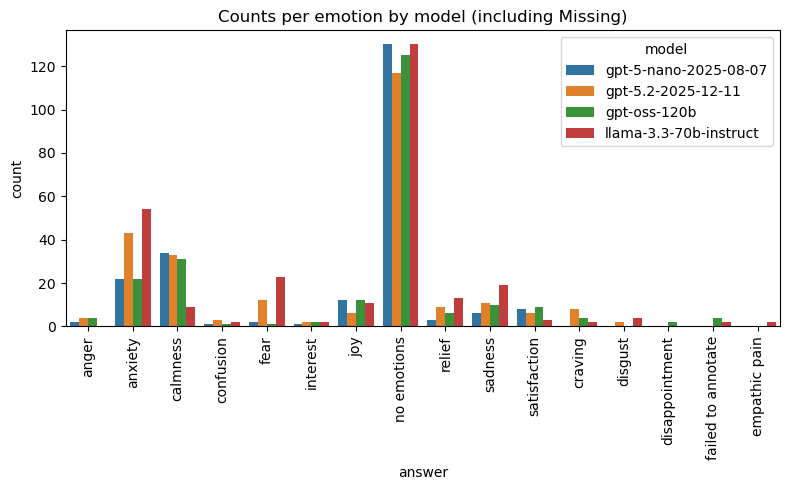

In [49]:

plt.figure(figsize=(8, 5))
sns.barplot(data=counts, x='answer', y='count', hue='model')
plt.title('Counts per emotion by model (including Missing)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

/tmp/reunamo1/5954775/ipykernel_4086003/1762313340.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.assign(prop=x['count'] / x['count'].sum()))


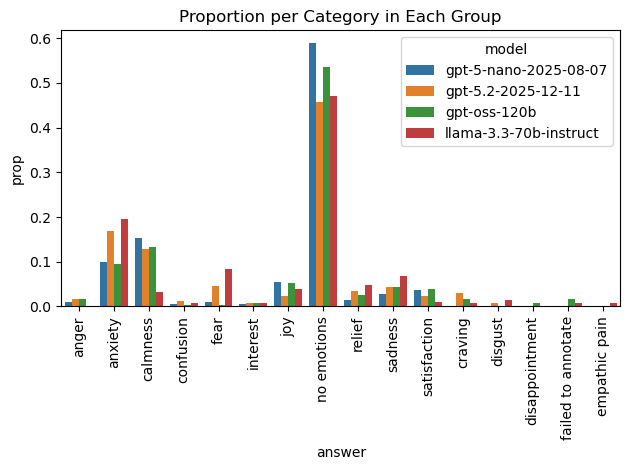

In [50]:
prop = (
    counts
    .groupby('model')
    .apply(lambda x: x.assign(prop=x['count'] / x['count'].sum()))
    .reset_index(drop=True)
)

sns.barplot(data=prop, x='answer', y='prop', hue='model')
plt.title("Proportion per Category in Each Group")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<Axes: xlabel='confidence', ylabel='Density'>

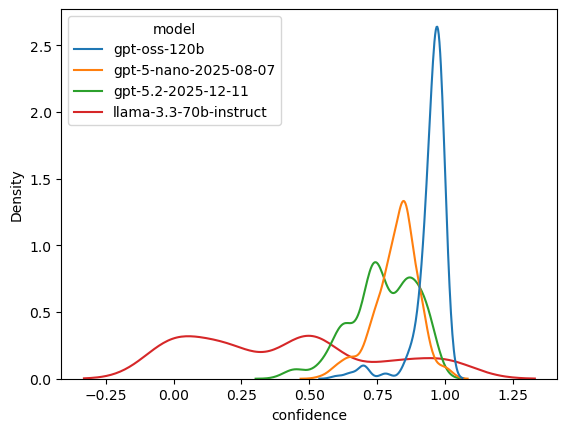

In [53]:
sns.kdeplot(df,x='confidence',hue='model')

In [13]:
no_justification = df[df['justification']=='None']

In [14]:
for r in no_justification.iterrows():
    print(r[1].loc['generated_text'])

In [15]:
no_emotions = df[df['answer'].isna()]

In [16]:
no_emotions

,model,prompt,generated_text,id,justification,answer,confidence
29,gpt-oss-120b,"<|start|>system<|message|>You are ChatGPT, a l...",assistantanalysisWe need patient emotions. Tex...,d0cdc58f-264e-405c-84e9-7985dbb5d565,None,None,NaN
113,gpt-oss-120b,"<|start|>system<|message|>You are ChatGPT, a l...",assistantanalysisWe need to parse the data. Th...,787b59ee-64f8-48a5-adb9-07624b13fd66,None,None,NaN
140,gpt-oss-120b,"<|start|>system<|message|>You are ChatGPT, a l...",assistantanalysisWe need patient emotions. Tex...,1cfde15d-aa87-4ff1-a592-fc6cd40949ca,None,None,NaN
615,llama-3.3-70b-instruct,<|begin_of_text|><|start_header_id|>system<|en...,"assistant\n\nTämä on potilaan hoitopäiväkirja,...",40c9e987-a88e-4dd5-aad0-ec7fa695b996,None,None,NaN
713,llama-3.3-70b-instruct,<|begin_of_text|><|start_header_id|>system<|en...,assistant\n\nPienin Verenpaine sys: 400\nSuuri...,787b59ee-64f8-48a5-adb9-07624b13fd66,None,None,NaN


In [19]:
for r in no_emotions.iterrows():
        print("text")
        print(r[1].loc['generated_text'])
        print()

text
assistantanalysisWe need patient emotions. Text mentions pain levels, feeling "hyvissä oloissa" (good condition) maybe calmness? Also "Erittäin selviytynyt" indicates pride or satisfaction. "Hän on edelleen huolehdyttynyt" maybe anxiety? "Huolehdyttynyt" = concerned. Could be anxiety. Also "Kivun seuranta Kipu vähentynyt, mutta ei katoa." not emotion. "Ruokaa maistuu huonosti" maybe disgust. So emotions: Anxiety, Pride, Disgust, Calmness? He is "selvinnyt hyvissä oloissa" suggests calmness or satisfaction. I'd pick Anxiety, Pride, Disgust, Calmness. Confidence moderate 0.6.assistantfinal**Justification:** The note states the patient is “huolehdyttynyt” (concerned) indicating anxiety, describes him as “erittäin selviytynyt” and “hyvissä oloissa,” suggesting pride and calmness/satisfaction, and notes that food “maistuu huonosti,” which reflects disgust. These are the only explicit emotional descriptors about the patient.

**Confidence:** 0.6

text
assistantanalysisWe need to parse t